In [8]:
%matplotlib notebook

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
import os
import time
import glob
from PIL import Image, ImageDraw, ImageFilter
import cv2


class FreehandPolygonDemo:
    def __init__(self, directory_path, output_directory):
        self.directory_path = directory_path
        self.image_files = sorted(glob.glob(os.path.join(directory_path, '*.jpg')))  # List all jpg files
        self.current_image_index = 0
        self.image = None
        self.fig, self.ax = None, None
        self.polygon = []  # Store current points
        self.polygons = {}  # Dictionary to store all polygons
        self.clear_count = 0  # Initialize clear count
        self.timestamps = {
            "first_click": None,
            "save_clicked": None
        }
        self.load_image()  # Load the first image automatically
        self.output_directory = output_directory
        
                # Ensure the output directory exists
        if not os.path.exists(self.output_directory):
            os.makedirs(self.output_directory)

    def load_image(self):
        """Load an image from a file and display it."""
        if self.image_files:
            image_path = self.image_files[self.current_image_index]
            self.image = plt.imread(image_path)
            self.show_image()
        else:
            print("No images found in the directory.")

    def show_image(self):
        """Show the image with interactive polygon drawing capabilities."""
        if self.image is not None:
            clear_output(wait=True)  # Clear previous outputs
            self.fig, self.ax = plt.subplots()
            self.ax.imshow(self.image)
            self.ax.axis('off')

            # Get the filename from the path and set it as the title of the plot
            filename = os.path.basename(self.image_files[self.current_image_index])
            self.ax.set_title(filename)  # Set the image filename as the title

            self.fig.canvas.mpl_connect('button_press_event', self.on_press)
            self.add_buttons()  # Add navigation and action buttons
        else:
            print("No image loaded.")

    def on_press(self, event):
        """Handle mouse button press events."""
        if event.inaxes != self.ax:
            return  # Ignore clicks outside the axes

        # Initialize timestamps and clear count for a new polygon
        if not self.polygon:  # Check if starting a new polygon
            self.timestamps = {
                "first_click": time.time(),
                "save_clicked": None
            }
            #self.clear_count = 0

        # Add the click position to the polygon points
        self.polygon.append((event.xdata, event.ydata))
        
        # Update the drawing
        if len(self.polygon) > 1:
            x, y = zip(*self.polygon)
            self.ax.plot(x, y, marker='o', linestyle='-', color='blue', markersize=4)
            #self.ax.fill(x, y, color='lightblue', alpha=0.3)
            #self.polygon.append(self.polygon[0])  # Close the polygon
            self.fig.canvas.draw()

    def add_buttons(self):
        """Add navigation and action buttons below the figure."""
        previous_button = widgets.Button(description="Previous")
        next_button = widgets.Button(description="Next")
        save_button = widgets.Button(description="Save")
        clear_button = widgets.Button(description="Clear")
        end_button = widgets.Button(description="End")
        previous_button.on_click(self.on_previous_clicked)
        next_button.on_click(self.on_next_clicked)
        save_button.on_click(self.on_save_clicked)
        clear_button.on_click(self.on_clear_clicked)
        end_button.on_click(self.on_end_clicked)
        button_box = widgets.HBox([previous_button, next_button, save_button, clear_button, end_button])
        display(button_box)

    def on_previous_clicked(self, b):
        """Go to the previous image."""
        if self.current_image_index > 0:
            self.current_image_index -= 1
            self.load_image()

    def on_next_clicked(self, b):
        """Go to the next image."""
        self.clear_count = 0
        if self.current_image_index < len(self.image_files) - 1:
            self.current_image_index += 1
            self.load_image()
            
    def on_save_clicked(self, b):
        """Handle Save button click: save polygon data as binary masks for current image."""
        if self.polygon:
            filename = os.path.basename(self.image_files[self.current_image_index])
            if filename not in self.polygons:
                self.polygons[filename] = []             
            
            # Retrieve the current image to get its dimensions
            image_path = self.image_files[self.current_image_index]
            with Image.open(image_path) as img:
                self.image_width, self.image_height = img.size

            # Convert polygon to a binary mask
            mask = Image.new('L', (self.image_width, self.image_height), 0)
            ImageDraw.Draw(mask).polygon(self.polygon, outline=0, fill=1)
            
            # Convert PIL Image to OpenCV format
            mask_array = np.array(mask)

            # Find contours
            contours, _ = cv2.findContours(mask_array, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Draw contours on a blank image
            mask_refined = np.zeros_like(mask_array)
            cv2.drawContours(mask_refined, contours, -1, (255), thickness=cv2.FILLED)

            # Convert back to PIL Image
            mask = Image.fromarray(mask_refined)
            
            # Save mask as a separate .png file
            mask_filename = f"{filename}"
            mask.save(os.path.join(self.output_directory, mask_filename))  # Specify the output directory


            # Save polygon data and mask
            self.timestamps["save_clicked"] = time.time()
            self.annotation_time= self.timestamps["save_clicked"]- self.timestamps["first_click"]
            polygon_data = {
                "polygon": list(self.polygon),
                "timestamps": self.timestamps,
                "clear_count": self.clear_count,
                "annotation_time": self.annotation_time
            }
            self.polygons[filename].append(polygon_data)
            self.polygon = []  # Reset the current polygon

            print(f"Polygon data and mask saved for {filename}. Total entries: {len(self.polygons[filename])}")

    def on_save_clicked2(self, b):
        """Handle Save button click: save polygon data for current image."""
        if self.polygon:
            filename = os.path.basename(self.image_files[self.current_image_index])
            if filename not in self.polygons:
                self.polygons[filename] = []
            self.timestamps["save_clicked"] = time.time()
            polygon_data = {
                "polygon": list(self.polygon),
                "timestamps": self.timestamps,
                "clear_count": self.clear_count
            }
            self.polygons[filename].append(polygon_data)
            self.polygon = []  # Reset the current polygon
            print(f"Polygon data saved for {filename}. Total entries: {len(self.polygons[filename])}")

    def on_clear_clicked(self, b):
        """Clear the drawing, reset polygon data, and increment clear count."""
        self.clear_count += 1  # Increment clear count
        self.polygon = []
        self.ax.clear()
        self.ax.imshow(self.image)
        self.ax.axis('off')
        self.fig.canvas.draw()
        print(f"Clear button clicked {self.clear_count} times.")  # Diagnostic message

    def on_end_clicked(self, b):
        """Save all polygon data to a JSON file when ending the session."""
        file_path = "all_polygon_data.json"
        with open(file_path, 'w') as f:
            json.dump(self.polygons, f, indent=4)
        print(f"All polygon data saved to {file_path}. Session ended.")

# Usage example
#demo = FreehandPolygonDemo("Images")  # Make sure the path is correct


<IPython.core.display.Javascript object>


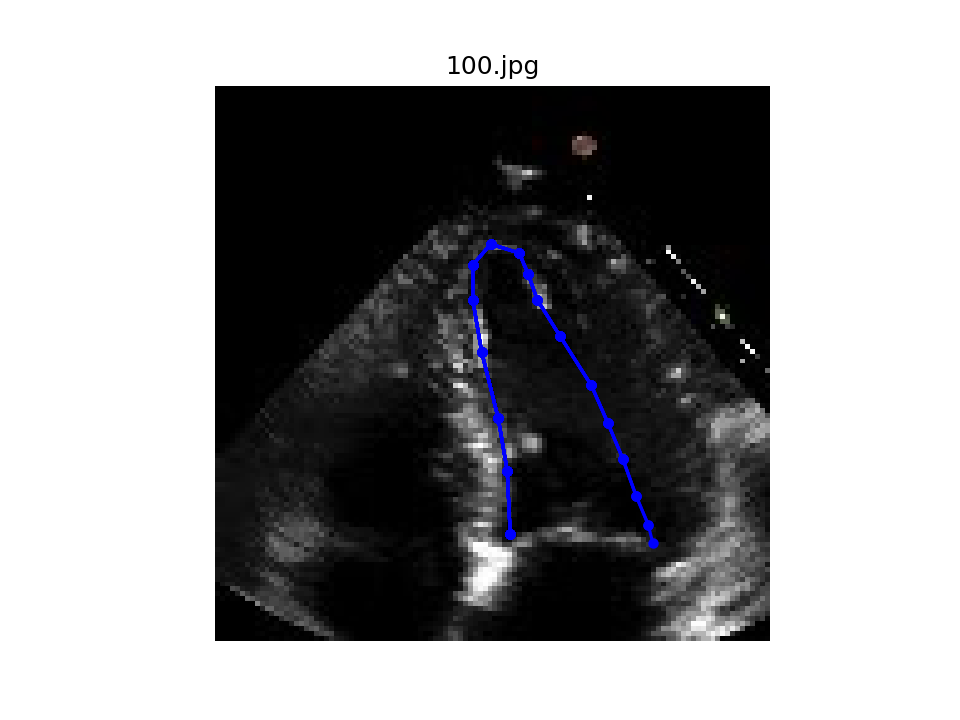

Polygon data and mask saved for 100.jpg. Total entries: 1
All polygon data saved to all_polygon_data.json. Session ended.


In [11]:
# Usage example
demo = FreehandPolygonDemo("Annotation Study", "FreeHand_result")  # Make sure the path is correct

In [7]:
#Optional: Check Mask Quality

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the image
image_path = r'C:\Users\m133326\Desktop\AI projects\SAM\FreeHand_result\100.jpg'
img = mpimg.imread(image_path)

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()
